### Imports

In [3]:
!pip install swig
!pip install "gymnasium[box2d]"

import os
import random
import heapq
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gymnasium as gym

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.distributions import Categorical

from dataclasses import dataclass
from collections import defaultdict

     ---------------------------------------- 2.5/2.5 MB 18.0 MB/s eta 0:00:00



[notice] A new release of pip available: 22.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


     ---------------------------------------- 1.3/1.3 MB 10.4 MB/s eta 0:00:00
     --------------------------------------- 10.6/10.6 MB 26.1 MB/s eta 0:00:00



[notice] A new release of pip available: 22.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### Global Setup

In [4]:
def make_lunarlander_env():
    try:
        return gym.make("LunarLander-v2")
    except Exception:
        return gym.make("LunarLander-v3")


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

env = make_lunarlander_env()

OBS_DIM = env.observation_space.shape[0]
N_ACTIONS = env.action_space.n

print("Environment:", env.spec.id)
print("Observation space:", env.observation_space)
print("Action space:", env.action_space)
print("Observation dimension:", OBS_DIM)
print("Number of actions:", N_ACTIONS)

env.close()

os.makedirs("checkpoints_week8", exist_ok=True)

Device: cuda
Environment: LunarLander-v3
Observation space: Box([ -2.5        -2.5       -10.        -10.         -6.2831855 -10.
  -0.         -0.       ], [ 2.5        2.5       10.        10.         6.2831855 10.
  1.         1.       ], (8,), float32)
Action space: Discrete(4)
Observation dimension: 8
Number of actions: 4


### Experiment Settings

In [5]:
SEEDS = [0, 1, 2]
NUM_EPISODES = 500
MAX_STEPS_PER_EPISODE = 1000
FINAL_WINDOW = 50

GAMMA = 0.99

### Plotting and Statistics Helpers

In [8]:
def moving_average(data, window_size=25):
    data = np.asarray(data, dtype=np.float64)

    if len(data) < window_size:
        return data

    kernel = np.ones(window_size) / window_size
    return np.convolve(data, kernel, mode="valid")


def mean_and_95_ci(data):

    data = np.asarray(data, dtype=np.float64)

    mean = np.mean(data, axis=0)
    std = np.std(data, axis=0, ddof=1)
    n = data.shape[0]

    ci = 1.96 * std / np.sqrt(n)

    return mean, ci


def smooth_mean_ci(mean, ci, window_size=25):
    mean_smooth = moving_average(mean, window_size)
    ci_smooth = moving_average(ci, window_size)

    x = np.arange(len(mean_smooth)) + window_size - 1

    return mean_smooth, ci_smooth, x


def plot_learning_curves(experiment_results, window_size=25):
    plt.figure(figsize=(12, 6))

    for algorithm_name, result in experiment_results.items():
        returns = result["returns"]

        mean, ci = mean_and_95_ci(returns)
        mean_smooth, ci_smooth, x = smooth_mean_ci(mean, ci, window_size)

        plt.plot(x, mean_smooth, label=algorithm_name)
        plt.fill_between(
            x,
            mean_smooth - ci_smooth,
            mean_smooth + ci_smooth,
            alpha=0.2
        )

    plt.title("LunarLander-v2 Learning Curves")
    plt.xlabel("Episode")
    plt.ylabel("Smoothed Episode Return")
    plt.legend()
    plt.grid(False)
    plt.show()


def plot_final_performance_bar(summary_df):
    plt.figure(figsize=(10, 6))

    x = np.arange(len(summary_df))
    means = summary_df["Final Mean Return"].values
    stds = summary_df["Final Std Return"].values
    labels = summary_df["Algorithm"].values

    plt.bar(x, means, yerr=stds, capsize=5)

    plt.title("Final Performance Comparison")
    plt.xlabel("Algorithm")
    plt.ylabel(f"Mean Return Over Last {FINAL_WINDOW} Episodes")
    plt.xticks(x, labels, rotation=25, ha="right")
    plt.grid(axis="y")
    plt.show()

### Epsilon Schedules

In [9]:
def constant_epsilon(epsilon_value):
    def schedule(episode):
        return epsilon_value
    return schedule


def linear_decay_epsilon(start=1.0, end=0.05, decay_episodes=400):
    def schedule(episode):
        fraction = min(episode / decay_episodes, 1.0)
        return start + fraction * (end - start)
    return schedule


def exponential_decay_epsilon(start=1.0, end=0.05, decay_rate=0.995):
    def schedule(episode):
        return max(end, start * (decay_rate ** episode))
    return schedule

### LunarLander Observation Discretizer Used by Dyna-Q

In [10]:
class LunarDiscretizer:
   
    def __init__(
        self,
        low=None,
        high=None,
        bins=(6, 6, 6, 6, 8, 8, 2, 2)
    ):
        if low is None:
            low = np.array([-1.5, -0.5, -2.0, -2.0, -np.pi, -5.0, 0.0, 0.0])

        if high is None:
            high = np.array([1.5, 1.5, 2.0, 2.0, np.pi, 5.0, 1.0, 1.0])

        self.low = np.asarray(low, dtype=np.float64)
        self.high = np.asarray(high, dtype=np.float64)
        self.bins = np.asarray(bins, dtype=np.int64)

        self.n_states = int(np.prod(self.bins))

    def discretize(self, obs):
        obs = np.asarray(obs, dtype=np.float64)
        obs = np.clip(obs, self.low, self.high)

        ratios = (obs - self.low) / (self.high - self.low + 1e-8)
        coords = np.floor(ratios * self.bins).astype(int)
        coords = np.clip(coords, 0, self.bins - 1)

        return int(np.ravel_multi_index(coords, self.bins))

    def describe(self):
        return {
            "bins": tuple(self.bins),
            "n_states": self.n_states,
            "low": self.low,
            "high": self.high
        }


discretizer = LunarDiscretizer()
discretizer.describe()

{'bins': (np.int64(6),
  np.int64(6),
  np.int64(6),
  np.int64(6),
  np.int64(8),
  np.int64(8),
  np.int64(2),
  np.int64(2)),
 'n_states': 331776,
 'low': array([-1.5       , -0.5       , -2.        , -2.        , -3.14159265,
        -5.        ,  0.        ,  0.        ]),
 'high': array([1.5       , 1.5       , 2.        , 2.        , 3.14159265,
        5.        , 1.        , 1.        ])}

### Dyna-Q with Discretized LunarLander States

In [11]:
@dataclass
class DynaQConfig:
    num_episodes: int = NUM_EPISODES
    max_steps_per_episode: int = MAX_STEPS_PER_EPISODE
    alpha: float = 0.1
    gamma: float = GAMMA
    epsilon_schedule: callable = linear_decay_epsilon(1.0, 0.05, 400)
    planning_steps: int = 20
    seed: int = 0
    bins: tuple = (6, 6, 6, 6, 8, 8, 2, 2)


def epsilon_greedy_discrete(Q, state_id, epsilon):
    if np.random.random() < epsilon:
        return int(np.random.choice(N_ACTIONS))

    return int(np.argmax(Q[state_id]))


def q_learning_update(Q, state, action, reward, next_state, terminated, alpha, gamma):
    if terminated:
        target = reward
    else:
        target = reward + gamma * np.max(Q[next_state])

    td_error = target - Q[state, action]
    Q[state, action] += alpha * td_error

    return td_error


def train_dyna_q_lunar(config):
    set_seed(config.seed)

    env = make_lunarlander_env()

    discretizer = LunarDiscretizer(bins=config.bins)

    Q = np.zeros((discretizer.n_states, N_ACTIONS), dtype=np.float64)
    model = {}

    episode_returns = np.zeros(config.num_episodes, dtype=np.float64)
    episode_lengths = np.zeros(config.num_episodes, dtype=np.int64)

    for episode in range(config.num_episodes):
        obs, info = env.reset(seed=config.seed + episode)
        state = discretizer.discretize(obs)

        epsilon = config.epsilon_schedule(episode)

        total_return = 0.0

        for step in range(config.max_steps_per_episode):
            action = epsilon_greedy_discrete(Q, state, epsilon)

            next_obs, reward, terminated, truncated, info = env.step(action)
            next_state = discretizer.discretize(next_obs)

            q_learning_update(
                Q=Q,
                state=state,
                action=action,
                reward=reward,
                next_state=next_state,
                terminated=terminated,
                alpha=config.alpha,
                gamma=config.gamma
            )

            model[(state, action)] = (reward, next_state, terminated)

            model_keys = list(model.keys())

            for _ in range(config.planning_steps):
                sim_state, sim_action = random.choice(model_keys)
                sim_reward, sim_next_state, sim_terminated = model[(sim_state, sim_action)]

                q_learning_update(
                    Q=Q,
                    state=sim_state,
                    action=sim_action,
                    reward=sim_reward,
                    next_state=sim_next_state,
                    terminated=sim_terminated,
                    alpha=config.alpha,
                    gamma=config.gamma
                )

            state = next_state
            total_return += reward

            if terminated or truncated:
                break

        episode_returns[episode] = total_return
        episode_lengths[episode] = step + 1

    env.close()

    return {
        "algorithm": "Dyna-Q",
        "Q": Q,
        "model": model,
        "discretizer": discretizer,
        "episode_returns": episode_returns,
        "episode_lengths": episode_lengths,
        "config": config
    }

### Hashed Tile Coder for LunarLander Used by Semi-Gradient SARSA

In [12]:
class HashedTileCoder:
    
    def __init__(
        self,
        low=None,
        high=None,
        num_tilings=8,
        tiles_per_dim=(6, 6, 6, 6, 8, 8, 2, 2),
        hash_size=8192
    ):
        if low is None:
            low = np.array([-1.5, -0.5, -2.0, -2.0, -np.pi, -5.0, 0.0, 0.0])

        if high is None:
            high = np.array([1.5, 1.5, 2.0, 2.0, np.pi, 5.0, 1.0, 1.0])

        self.low = np.asarray(low, dtype=np.float64)
        self.high = np.asarray(high, dtype=np.float64)

        self.num_tilings = int(num_tilings)
        self.tiles_per_dim = np.asarray(tiles_per_dim, dtype=np.int64)
        self.hash_size = int(hash_size)

        self.num_dims = len(self.low)
        self.state_range = self.high - self.low

        self.tile_width = self.state_range / np.maximum(self.tiles_per_dim - 1, 1)

        self.offsets = self._make_offsets()

    def _make_offsets(self):
        offsets = np.zeros((self.num_tilings, self.num_dims), dtype=np.float64)

        for tiling in range(self.num_tilings):
            fraction = tiling / self.num_tilings

            for dim in range(self.num_dims):
                offsets[tiling, dim] = fraction * self.tile_width[dim]

        return offsets

    def get_active_tiles(self, obs):
        obs = np.asarray(obs, dtype=np.float64)
        obs = np.clip(obs, self.low, self.high)

        active_indices = []

        for tiling in range(self.num_tilings):
            shifted_obs = obs - self.low + self.offsets[tiling]

            coords = np.floor(shifted_obs / (self.tile_width + 1e-8)).astype(int)
            coords = np.clip(coords, 0, self.tiles_per_dim - 1)

            key = tuple([tiling] + coords.tolist())
            hashed_index = hash(key) % self.hash_size

            active_indices.append(hashed_index)

        return np.array(active_indices, dtype=np.int64)

    def describe(self):
        return {
            "num_tilings": self.num_tilings,
            "tiles_per_dim": tuple(self.tiles_per_dim),
            "hash_size": self.hash_size,
            "active_features": self.num_tilings
        }


tile_coder = HashedTileCoder()
tile_coder.describe()

{'num_tilings': 8,
 'tiles_per_dim': (np.int64(6),
  np.int64(6),
  np.int64(6),
  np.int64(6),
  np.int64(8),
  np.int64(8),
  np.int64(2),
  np.int64(2)),
 'hash_size': 8192,
 'active_features': 8}

### Semi-Gradient SARSA with Tile Coding

In [13]:
@dataclass
class TileSarsaConfig:
    num_episodes: int = NUM_EPISODES
    max_steps_per_episode: int = MAX_STEPS_PER_EPISODE
    alpha: float = 0.2
    gamma: float = GAMMA
    epsilon_schedule: callable = linear_decay_epsilon(1.0, 0.05, 400)
    num_tilings: int = 8
    tiles_per_dim: tuple = (6, 6, 6, 6, 8, 8, 2, 2)
    hash_size: int = 8192
    seed: int = 0


class TileSarsaAgent:
    def __init__(self, tile_coder, alpha=0.2, gamma=0.99, seed=0):
        self.tile_coder = tile_coder
        self.alpha = alpha / tile_coder.num_tilings
        self.gamma = gamma
        self.rng = np.random.default_rng(seed)

        self.weights = np.zeros((N_ACTIONS, tile_coder.hash_size), dtype=np.float64)

    def q_value(self, obs, action):
        active_tiles = self.tile_coder.get_active_tiles(obs)
        return np.sum(self.weights[action, active_tiles])

    def q_values(self, obs):
        active_tiles = self.tile_coder.get_active_tiles(obs)
        return np.sum(self.weights[:, active_tiles], axis=1)

    def select_action(self, obs, epsilon):
        if self.rng.random() < epsilon:
            return int(self.rng.choice(N_ACTIONS))

        return int(np.argmax(self.q_values(obs)))

    def update(self, obs, action, target):
        active_tiles = self.tile_coder.get_active_tiles(obs)

        prediction = np.sum(self.weights[action, active_tiles])
        td_error = target - prediction

        self.weights[action, active_tiles] += self.alpha * td_error

        return td_error


def train_tile_sarsa_lunar(config):
    set_seed(config.seed)

    env = make_lunarlander_env()

    tile_coder = HashedTileCoder(
        num_tilings=config.num_tilings,
        tiles_per_dim=config.tiles_per_dim,
        hash_size=config.hash_size
    )

    agent = TileSarsaAgent(
        tile_coder=tile_coder,
        alpha=config.alpha,
        gamma=config.gamma,
        seed=config.seed
    )

    episode_returns = np.zeros(config.num_episodes, dtype=np.float64)
    episode_lengths = np.zeros(config.num_episodes, dtype=np.int64)

    for episode in range(config.num_episodes):
        obs, info = env.reset(seed=config.seed + episode)

        epsilon = config.epsilon_schedule(episode)

        action = agent.select_action(obs, epsilon)

        total_return = 0.0

        for step in range(config.max_steps_per_episode):
            next_obs, reward, terminated, truncated, info = env.step(action)

            if terminated:
                target = reward
                agent.update(obs, action, target)
                total_return += reward
                break

            next_action = agent.select_action(next_obs, epsilon)
            next_q = agent.q_value(next_obs, next_action)

            target = reward + config.gamma * next_q
            agent.update(obs, action, target)

            obs = next_obs
            action = next_action

            total_return += reward

            if truncated:
                break

        episode_returns[episode] = total_return
        episode_lengths[episode] = step + 1

    env.close()

    return {
        "algorithm": "Tile-coded SARSA",
        "agent": agent,
        "tile_coder": tile_coder,
        "weights": agent.weights,
        "episode_returns": episode_returns,
        "episode_lengths": episode_lengths,
        "config": config
    }

### Reinforce with Baseline

In [14]:
@dataclass
class ReinforceBaselineConfig:
    num_episodes: int = NUM_EPISODES
    max_steps_per_episode: int = MAX_STEPS_PER_EPISODE
    gamma: float = GAMMA
    policy_lr: float = 1e-3
    value_lr: float = 1e-3
    hidden_sizes: tuple = (128, 128)
    normalize_advantages: bool = True
    seed: int = 0


class PolicyNetwork(nn.Module):
    def __init__(self, obs_dim, n_actions, hidden_sizes=(128, 128)):
        super().__init__()

        layers = []
        input_dim = obs_dim

        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(input_dim, hidden_size))
            layers.append(nn.ReLU())
            input_dim = hidden_size

        self.body = nn.Sequential(*layers)
        self.logits_head = nn.Linear(input_dim, n_actions)

    def forward(self, obs):
        x = self.body(obs)
        logits = self.logits_head(x)
        return logits

    def distribution(self, obs):
        logits = self.forward(obs)
        probs = F.softmax(logits, dim=-1)
        return Categorical(probs=probs)


class ValueNetwork(nn.Module):
    def __init__(self, obs_dim, hidden_sizes=(128, 128)):
        super().__init__()

        layers = []
        input_dim = obs_dim

        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(input_dim, hidden_size))
            layers.append(nn.ReLU())
            input_dim = hidden_size

        self.body = nn.Sequential(*layers)
        self.value_head = nn.Linear(input_dim, 1)

    def forward(self, obs):
        x = self.body(obs)
        value = self.value_head(x)
        return value.squeeze(-1)


def compute_returns(rewards, gamma=0.99):
    returns = []
    G = 0.0

    for reward in reversed(rewards):
        G = reward + gamma * G
        returns.append(G)

    returns.reverse()

    return torch.tensor(returns, dtype=torch.float32, device=DEVICE)


def normalize_tensor(x, eps=1e-8):
    if x.numel() <= 1:
        return x

    return (x - x.mean()) / (x.std(unbiased=False) + eps)


def collect_reinforce_episode(env, policy_net, max_steps, seed=None):
    obs, info = env.reset(seed=seed)

    observations = []
    actions = []
    log_probs = []
    rewards = []
    entropies = []

    for step in range(max_steps):
        obs_tensor = torch.tensor(obs, dtype=torch.float32, device=DEVICE).unsqueeze(0)

        dist = policy_net.distribution(obs_tensor)
        action_tensor = dist.sample()
        log_prob = dist.log_prob(action_tensor)
        entropy = dist.entropy()

        action = int(action_tensor.item())

        next_obs, reward, terminated, truncated, info = env.step(action)

        observations.append(obs)
        actions.append(action)
        log_probs.append(log_prob.squeeze(0))
        rewards.append(float(reward))
        entropies.append(entropy.squeeze(0))

        obs = next_obs

        if terminated or truncated:
            break

    return {
        "observations": torch.tensor(np.array(observations), dtype=torch.float32, device=DEVICE),
        "actions": torch.tensor(actions, dtype=torch.long, device=DEVICE),
        "log_probs": torch.stack(log_probs),
        "rewards": rewards,
        "entropies": torch.stack(entropies),
        "episode_return": float(np.sum(rewards)),
        "episode_length": len(rewards)
    }


def train_reinforce_baseline_lunar(config):
    set_seed(config.seed)

    env = make_lunarlander_env()

    policy_net = PolicyNetwork(
        obs_dim=OBS_DIM,
        n_actions=N_ACTIONS,
        hidden_sizes=config.hidden_sizes
    ).to(DEVICE)

    value_net = ValueNetwork(
        obs_dim=OBS_DIM,
        hidden_sizes=config.hidden_sizes
    ).to(DEVICE)

    policy_optimizer = optim.Adam(policy_net.parameters(), lr=config.policy_lr)
    value_optimizer = optim.Adam(value_net.parameters(), lr=config.value_lr)

    episode_returns = np.zeros(config.num_episodes, dtype=np.float64)
    episode_lengths = np.zeros(config.num_episodes, dtype=np.int64)
    policy_losses = np.zeros(config.num_episodes, dtype=np.float64)
    value_losses = np.zeros(config.num_episodes, dtype=np.float64)
    entropy_values = np.zeros(config.num_episodes, dtype=np.float64)

    for episode in range(config.num_episodes):
        episode_data = collect_reinforce_episode(
            env=env,
            policy_net=policy_net,
            max_steps=config.max_steps_per_episode,
            seed=config.seed + episode
        )

        observations = episode_data["observations"]
        log_probs = episode_data["log_probs"]
        returns = compute_returns(episode_data["rewards"], gamma=config.gamma)

        values = value_net(observations)
        advantages = returns - values.detach()

        if config.normalize_advantages:
            advantages_for_loss = normalize_tensor(advantages)
        else:
            advantages_for_loss = advantages

        policy_loss = -(log_probs * advantages_for_loss).sum()
        value_loss = F.mse_loss(values, returns)

        policy_optimizer.zero_grad()
        policy_loss.backward()
        policy_optimizer.step()

        value_optimizer.zero_grad()
        value_loss.backward()
        value_optimizer.step()

        episode_returns[episode] = episode_data["episode_return"]
        episode_lengths[episode] = episode_data["episode_length"]
        policy_losses[episode] = policy_loss.item()
        value_losses[episode] = value_loss.item()
        entropy_values[episode] = episode_data["entropies"].mean().item()

    env.close()

    return {
        "algorithm": "REINFORCE with Baseline",
        "policy_net": policy_net,
        "value_net": value_net,
        "episode_returns": episode_returns,
        "episode_lengths": episode_lengths,
        "policy_losses": policy_losses,
        "value_losses": value_losses,
        "entropy_values": entropy_values,
        "config": config
    }

### Multi-Seed Runners

In [15]:
def run_dyna_q_multiseed(seeds=SEEDS):
    results = []

    for seed in seeds:
        print(f"Training Dyna-Q | seed={seed}")

        config = DynaQConfig(
            num_episodes=NUM_EPISODES,
            max_steps_per_episode=MAX_STEPS_PER_EPISODE,
            alpha=0.1,
            gamma=GAMMA,
            epsilon_schedule=linear_decay_epsilon(1.0, 0.05, 400),
            planning_steps=20,
            seed=seed,
            bins=(6, 6, 6, 6, 8, 8, 2, 2)
        )

        result = train_dyna_q_lunar(config)
        results.append(result)

    return {
        "algorithm": "Dyna-Q",
        "results": results,
        "returns": np.array([r["episode_returns"] for r in results]),
        "lengths": np.array([r["episode_lengths"] for r in results])
    }


def run_tile_sarsa_multiseed(seeds=SEEDS):
    results = []

    for seed in seeds:
        print(f"Training Tile-coded SARSA | seed={seed}")

        config = TileSarsaConfig(
            num_episodes=NUM_EPISODES,
            max_steps_per_episode=MAX_STEPS_PER_EPISODE,
            alpha=0.2,
            gamma=GAMMA,
            epsilon_schedule=linear_decay_epsilon(1.0, 0.05, 400),
            num_tilings=8,
            tiles_per_dim=(6, 6, 6, 6, 8, 8, 2, 2),
            hash_size=8192,
            seed=seed
        )

        result = train_tile_sarsa_lunar(config)
        results.append(result)

    return {
        "algorithm": "Tile-coded SARSA",
        "results": results,
        "returns": np.array([r["episode_returns"] for r in results]),
        "lengths": np.array([r["episode_lengths"] for r in results])
    }


def run_reinforce_baseline_multiseed(seeds=SEEDS):
    results = []

    for seed in seeds:
        print(f"Training REINFORCE with Baseline | seed={seed}")

        config = ReinforceBaselineConfig(
            num_episodes=NUM_EPISODES,
            max_steps_per_episode=MAX_STEPS_PER_EPISODE,
            gamma=GAMMA,
            policy_lr=1e-3,
            value_lr=1e-3,
            hidden_sizes=(128, 128),
            normalize_advantages=True,
            seed=seed
        )

        result = train_reinforce_baseline_lunar(config)
        results.append(result)

    return {
        "algorithm": "REINFORCE with Baseline",
        "results": results,
        "returns": np.array([r["episode_returns"] for r in results]),
        "lengths": np.array([r["episode_lengths"] for r in results])
    }

### Run Main Experiments

In [16]:
dyna_q_results = run_dyna_q_multiseed(SEEDS)
tile_sarsa_results = run_tile_sarsa_multiseed(SEEDS)
reinforce_baseline_results = run_reinforce_baseline_multiseed(SEEDS)

experiment_results = {
    "Dyna-Q": dyna_q_results,
    "Tile-coded SARSA": tile_sarsa_results,
    "REINFORCE with Baseline": reinforce_baseline_results
}

Training Dyna-Q | seed=0


c:\Users\jurge\python_virtualenvs\data-science\Lib\site-packages\gymnasium\envs\registration.py:512: DeprecationWarning: WARN: The environment LunarLander-v2 is out of date. You should consider upgrading to version `v3`.
  logger.deprecation(


Training Dyna-Q | seed=1
Training Dyna-Q | seed=2
Training Tile-coded SARSA | seed=0
Training Tile-coded SARSA | seed=1
Training Tile-coded SARSA | seed=2
Training REINFORCE with Baseline | seed=0
Training REINFORCE with Baseline | seed=1


c:\Users\jurge\python_virtualenvs\data-science\Lib\site-packages\gymnasium\envs\registration.py:512: DeprecationWarning: WARN: The environment LunarLander-v2 is out of date. You should consider upgrading to version `v3`.
  logger.deprecation(


Training REINFORCE with Baseline | seed=2


### Main Learning Curve Plot

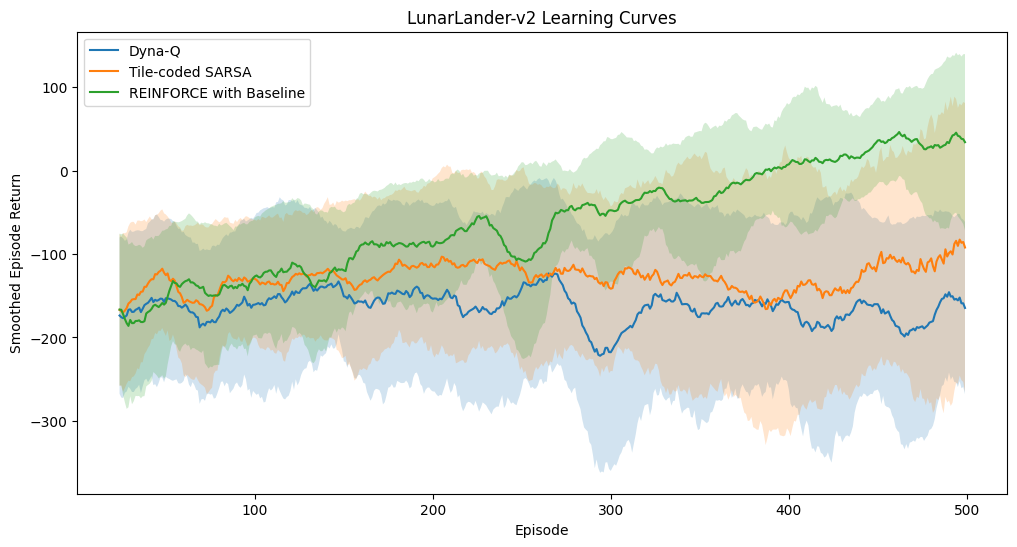

In [17]:
plot_learning_curves(
    experiment_results,
    window_size=25
)

### Final Performance Table

In [18]:
def summarize_algorithm(name, result, final_window=FINAL_WINDOW):
    returns = result["returns"]
    lengths = result["lengths"]

    final_returns = returns[:, -final_window:]
    final_lengths = lengths[:, -final_window:]

    return {
        "Algorithm": name,
        "Final Mean Return": np.mean(final_returns),
        "Final Std Return": np.std(np.mean(final_returns, axis=1), ddof=1),
        "Final Mean Length": np.mean(final_lengths),
        "Final Std Length": np.std(np.mean(final_lengths, axis=1), ddof=1),
        "Best Seed Final Return": np.max(np.mean(final_returns, axis=1)),
        "Worst Seed Final Return": np.min(np.mean(final_returns, axis=1))
    }


summary_rows = []

for name, result in experiment_results.items():
    summary_rows.append(summarize_algorithm(name, result))

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.round(2)

summary_df

,Algorithm,Final Mean Return,Final Std Return,Final Mean Length,Final Std Length,Best Seed Final Return,Worst Seed Final Return
0,Dyna-Q,-176.1,9.53,130.87,3.58,-169.84,-187.06
1,Tile-coded SARSA,-99.2,14.24,236.09,23.40,-83.55,-111.40
2,REINFORCE with Baseline,32.6,41.64,554.71,143.61,57.56,-15.47


### Final Performance Bar Chart

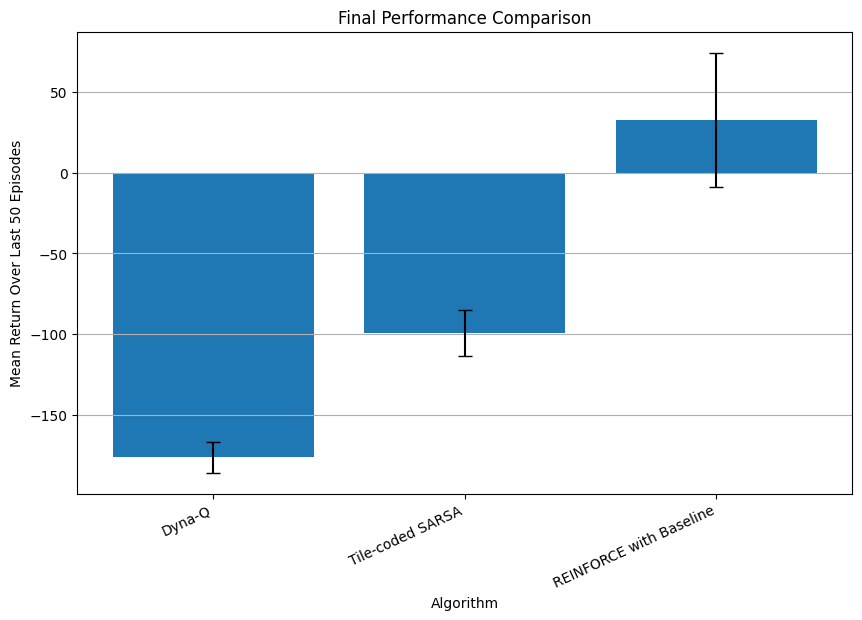

In [19]:
plot_final_performance_bar(summary_df)

### Episode Length Curve

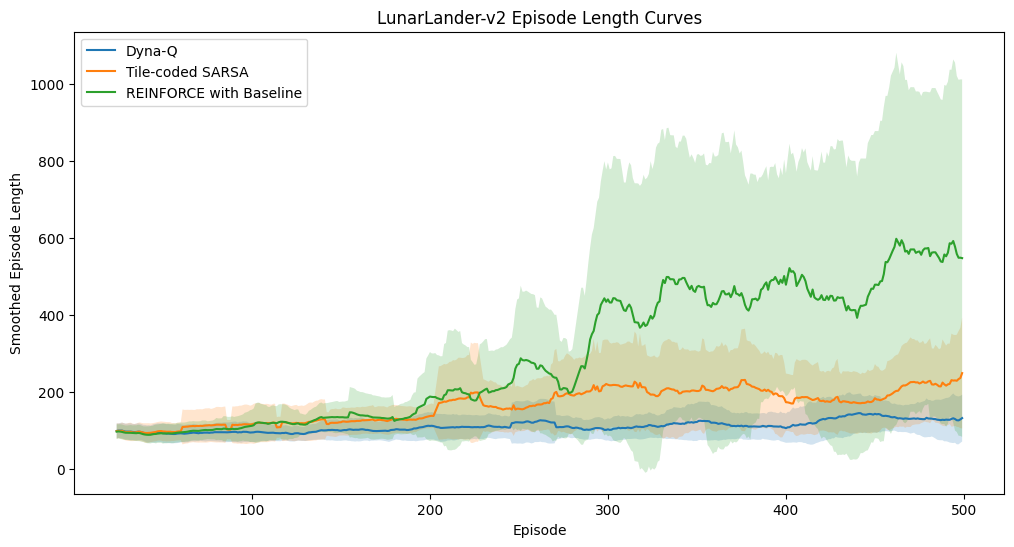

In [20]:
def plot_episode_length_curves(experiment_results, window_size=25):
    plt.figure(figsize=(12, 6))

    for algorithm_name, result in experiment_results.items():
        lengths = result["lengths"]

        mean, ci = mean_and_95_ci(lengths)
        mean_smooth, ci_smooth, x = smooth_mean_ci(mean, ci, window_size)

        plt.plot(x, mean_smooth, label=algorithm_name)
        plt.fill_between(
            x,
            mean_smooth - ci_smooth,
            mean_smooth + ci_smooth,
            alpha=0.2
        )

    plt.title("LunarLander-v2 Episode Length Curves")
    plt.xlabel("Episode")
    plt.ylabel("Smoothed Episode Length")
    plt.legend()
    plt.grid(False)
    plt.show()


plot_episode_length_curves(
    experiment_results,
    window_size=25
)

### Greedy Evaluation Helpers

In [21]:
def evaluate_dyna_q_policy(result, num_eval_episodes=20, seed=10_000):
    env = make_lunarlander_env()

    Q = result["Q"]
    discretizer = result["discretizer"]

    returns = []
    lengths = []

    for episode in range(num_eval_episodes):
        obs, info = env.reset(seed=seed + episode)

        total_return = 0.0

        for step in range(MAX_STEPS_PER_EPISODE):
            state = discretizer.discretize(obs)
            action = int(np.argmax(Q[state]))

            obs, reward, terminated, truncated, info = env.step(action)

            total_return += reward

            if terminated or truncated:
                break

        returns.append(total_return)
        lengths.append(step + 1)

    env.close()

    return np.array(returns), np.array(lengths)


def evaluate_tile_sarsa_policy(result, num_eval_episodes=20, seed=10_000):
    env = make_lunarlander_env()

    agent = result["agent"]

    returns = []
    lengths = []

    for episode in range(num_eval_episodes):
        obs, info = env.reset(seed=seed + episode)

        total_return = 0.0

        for step in range(MAX_STEPS_PER_EPISODE):
            action = int(np.argmax(agent.q_values(obs)))

            obs, reward, terminated, truncated, info = env.step(action)

            total_return += reward

            if terminated or truncated:
                break

        returns.append(total_return)
        lengths.append(step + 1)

    env.close()

    return np.array(returns), np.array(lengths)


def evaluate_reinforce_policy(result, num_eval_episodes=20, seed=10_000):
    env = make_lunarlander_env()

    policy_net = result["policy_net"]
    policy_net.eval()

    returns = []
    lengths = []

    for episode in range(num_eval_episodes):
        obs, info = env.reset(seed=seed + episode)

        total_return = 0.0

        for step in range(MAX_STEPS_PER_EPISODE):
            obs_tensor = torch.tensor(obs, dtype=torch.float32, device=DEVICE).unsqueeze(0)

            with torch.no_grad():
                logits = policy_net(obs_tensor)
                action = int(torch.argmax(logits, dim=-1).item())

            obs, reward, terminated, truncated, info = env.step(action)

            total_return += reward

            if terminated or truncated:
                break

        returns.append(total_return)
        lengths.append(step + 1)

    env.close()

    policy_net.train()

    return np.array(returns), np.array(lengths)

### Evaluating Best Seed From Each Algorithm

In [22]:
def get_best_seed_result(result_group):
    returns = result_group["returns"]
    final_means = np.mean(returns[:, -FINAL_WINDOW:], axis=1)
    best_idx = int(np.argmax(final_means))
    return result_group["results"][best_idx], best_idx


best_dyna_q, best_dyna_seed_idx = get_best_seed_result(dyna_q_results)
best_tile_sarsa, best_tile_seed_idx = get_best_seed_result(tile_sarsa_results)
best_reinforce, best_reinforce_seed_idx = get_best_seed_result(reinforce_baseline_results)

dyna_eval_returns, dyna_eval_lengths = evaluate_dyna_q_policy(best_dyna_q)
sarsa_eval_returns, sarsa_eval_lengths = evaluate_tile_sarsa_policy(best_tile_sarsa)
reinforce_eval_returns, reinforce_eval_lengths = evaluate_reinforce_policy(best_reinforce)

eval_summary_df = pd.DataFrame([
    {
        "Algorithm": "Dyna-Q",
        "Eval Mean Return": np.mean(dyna_eval_returns),
        "Eval Std Return": np.std(dyna_eval_returns, ddof=1),
        "Eval Mean Length": np.mean(dyna_eval_lengths),
        "Best Training Seed Index": best_dyna_seed_idx
    },
    {
        "Algorithm": "Tile-coded SARSA",
        "Eval Mean Return": np.mean(sarsa_eval_returns),
        "Eval Std Return": np.std(sarsa_eval_returns, ddof=1),
        "Eval Mean Length": np.mean(sarsa_eval_lengths),
        "Best Training Seed Index": best_tile_seed_idx
    },
    {
        "Algorithm": "REINFORCE with Baseline",
        "Eval Mean Return": np.mean(reinforce_eval_returns),
        "Eval Std Return": np.std(reinforce_eval_returns, ddof=1),
        "Eval Mean Length": np.mean(reinforce_eval_lengths),
        "Best Training Seed Index": best_reinforce_seed_idx
    }
]).round(2)

eval_summary_df

c:\Users\jurge\python_virtualenvs\data-science\Lib\site-packages\gymnasium\envs\registration.py:512: DeprecationWarning: WARN: The environment LunarLander-v2 is out of date. You should consider upgrading to version `v3`.
  logger.deprecation(


,Algorithm,Eval Mean Return,Eval Std Return,Eval Mean Length,Best Training Seed Index
0,Dyna-Q,-250.23,103.89,188.75,1
1,Tile-coded SARSA,-98.80,187.22,282.20,1
2,REINFORCE with Baseline,-48.26,19.54,1000.00,2


### Plotting Evaluation Bar Chart

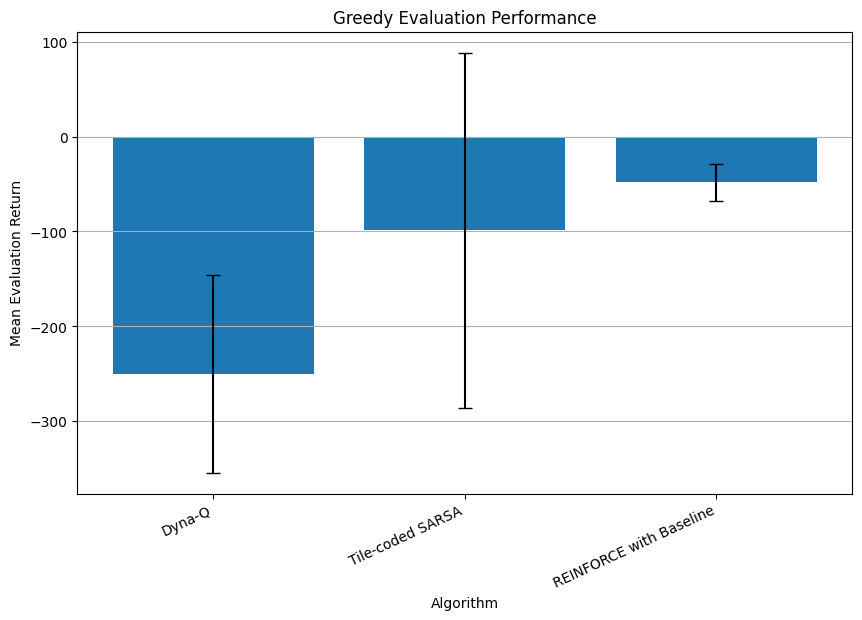

In [23]:
def plot_eval_performance_bar(eval_summary_df):
    plt.figure(figsize=(10, 6))

    x = np.arange(len(eval_summary_df))
    means = eval_summary_df["Eval Mean Return"].values
    stds = eval_summary_df["Eval Std Return"].values
    labels = eval_summary_df["Algorithm"].values

    plt.bar(x, means, yerr=stds, capsize=5)

    plt.title("Greedy Evaluation Performance")
    plt.xlabel("Algorithm")
    plt.ylabel("Mean Evaluation Return")
    plt.xticks(x, labels, rotation=25, ha="right")
    plt.grid(axis="y")
    plt.show()


plot_eval_performance_bar(eval_summary_df)

### Hyperparameter Tunning -Dyna-Q Planning Steps

In [24]:
RUN_HYPERPARAMETER_TUNING = True

dyna_planning_values = [5, 20, 50]

dyna_tuning_results = {}

if RUN_HYPERPARAMETER_TUNING:
    for planning_steps in dyna_planning_values:
        print(f"Dyna-Q tuning | planning_steps={planning_steps}")

        tuning_runs = []

        for seed in SEEDS:
            config = DynaQConfig(
                num_episodes=NUM_EPISODES,
                max_steps_per_episode=MAX_STEPS_PER_EPISODE,
                alpha=0.1,
                gamma=GAMMA,
                epsilon_schedule=linear_decay_epsilon(1.0, 0.05, 400),
                planning_steps=planning_steps,
                seed=seed,
                bins=(6, 6, 6, 6, 8, 8, 2, 2)
            )

            tuning_runs.append(train_dyna_q_lunar(config))

        dyna_tuning_results[f"planning={planning_steps}"] = {
            "returns": np.array([r["episode_returns"] for r in tuning_runs]),
            "lengths": np.array([r["episode_lengths"] for r in tuning_runs]),
            "results": tuning_runs
        }

Dyna-Q tuning | planning_steps=5


c:\Users\jurge\python_virtualenvs\data-science\Lib\site-packages\gymnasium\envs\registration.py:512: DeprecationWarning: WARN: The environment LunarLander-v2 is out of date. You should consider upgrading to version `v3`.
  logger.deprecation(


Dyna-Q tuning | planning_steps=20
Dyna-Q tuning | planning_steps=50


### Hyperparameter Tunning - Tile SARSA Alpha

In [25]:
sarsa_alpha_values = [0.1, 0.2, 0.4]

sarsa_tuning_results = {}

if RUN_HYPERPARAMETER_TUNING:
    for alpha in sarsa_alpha_values:
        print(f"Tile-coded SARSA tuning | alpha={alpha}")

        tuning_runs = []

        for seed in SEEDS:
            config = TileSarsaConfig(
                num_episodes=NUM_EPISODES,
                max_steps_per_episode=MAX_STEPS_PER_EPISODE,
                alpha=alpha,
                gamma=GAMMA,
                epsilon_schedule=linear_decay_epsilon(1.0, 0.05, 400),
                num_tilings=8,
                tiles_per_dim=(6, 6, 6, 6, 8, 8, 2, 2),
                hash_size=8192,
                seed=seed
            )

            tuning_runs.append(train_tile_sarsa_lunar(config))

        sarsa_tuning_results[f"alpha={alpha}"] = {
            "returns": np.array([r["episode_returns"] for r in tuning_runs]),
            "lengths": np.array([r["episode_lengths"] for r in tuning_runs]),
            "results": tuning_runs
        }

Tile-coded SARSA tuning | alpha=0.1
Tile-coded SARSA tuning | alpha=0.2
Tile-coded SARSA tuning | alpha=0.4


### Hyperparameter Tunning - REINFORCE Policy Learning Rate

In [26]:
reinforce_lr_values = [5e-4, 1e-3, 3e-3]

reinforce_tuning_results = {}

if RUN_HYPERPARAMETER_TUNING:
    for policy_lr in reinforce_lr_values:
        print(f"REINFORCE tuning | policy_lr={policy_lr}")

        tuning_runs = []

        for seed in SEEDS:
            config = ReinforceBaselineConfig(
                num_episodes=NUM_EPISODES,
                max_steps_per_episode=MAX_STEPS_PER_EPISODE,
                gamma=GAMMA,
                policy_lr=policy_lr,
                value_lr=1e-3,
                hidden_sizes=(128, 128),
                normalize_advantages=True,
                seed=seed
            )

            tuning_runs.append(train_reinforce_baseline_lunar(config))

        reinforce_tuning_results[f"lr={policy_lr}"] = {
            "returns": np.array([r["episode_returns"] for r in tuning_runs]),
            "lengths": np.array([r["episode_lengths"] for r in tuning_runs]),
            "results": tuning_runs
        }

REINFORCE tuning | policy_lr=0.0005
REINFORCE tuning | policy_lr=0.001
REINFORCE tuning | policy_lr=0.003


### Plotting Hyperparameter Tuning Results

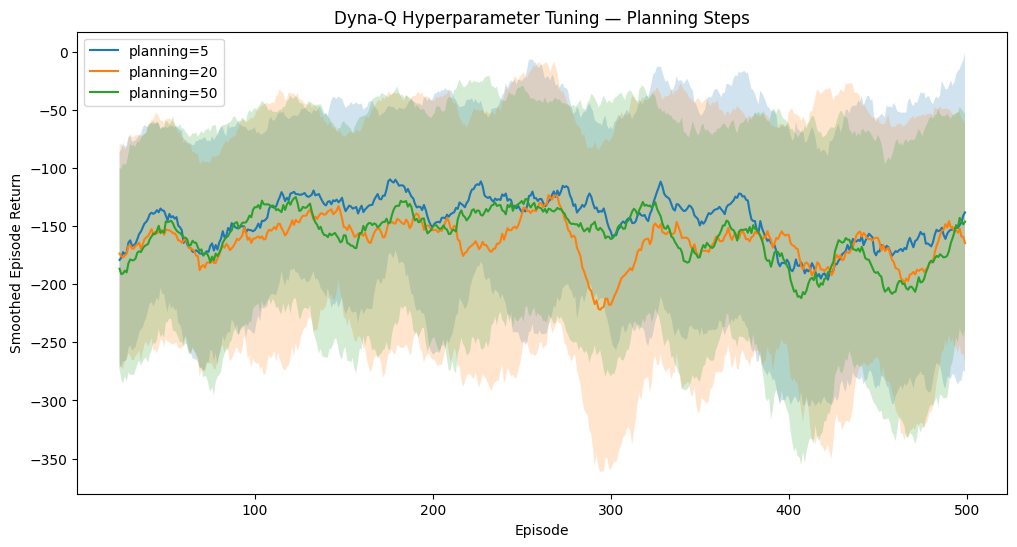

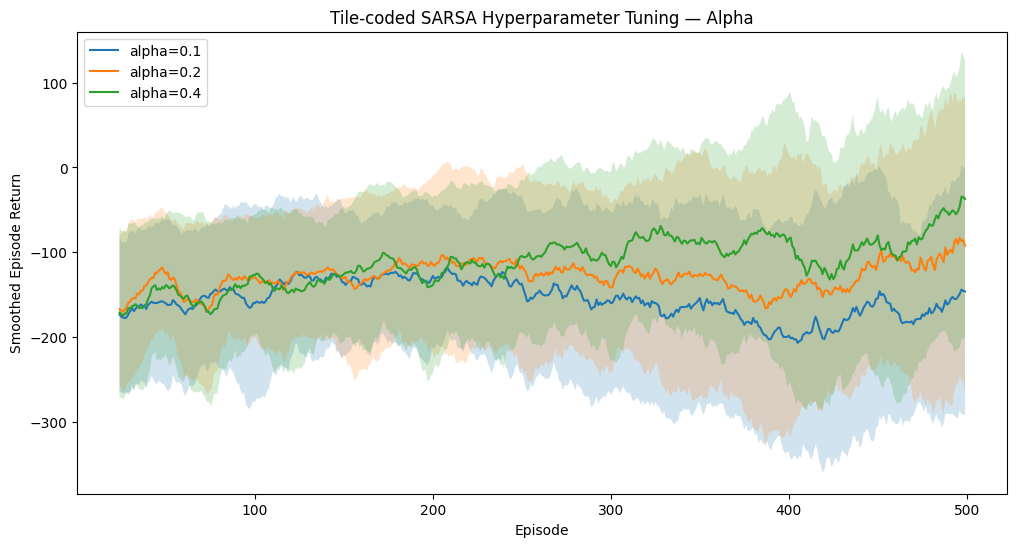

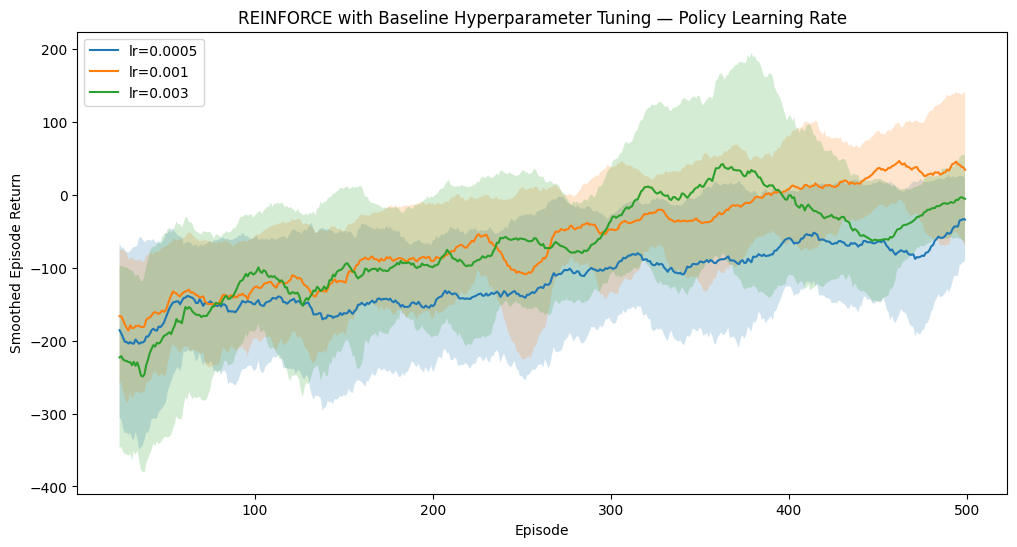

In [27]:
def plot_tuning_results(tuning_results, title, window_size=25):
    plt.figure(figsize=(12, 6))

    for label, result in tuning_results.items():
        returns = result["returns"]

        mean, ci = mean_and_95_ci(returns)
        mean_smooth, ci_smooth, x = smooth_mean_ci(mean, ci, window_size)

        plt.plot(x, mean_smooth, label=label)
        plt.fill_between(
            x,
            mean_smooth - ci_smooth,
            mean_smooth + ci_smooth,
            alpha=0.2
        )

    plt.title(title)
    plt.xlabel("Episode")
    plt.ylabel("Smoothed Episode Return")
    plt.legend()
    plt.grid(False)
    plt.show()


if RUN_HYPERPARAMETER_TUNING:
    plot_tuning_results(
        dyna_tuning_results,
        title="Dyna-Q Hyperparameter Tuning — Planning Steps",
        window_size=25
    )

    plot_tuning_results(
        sarsa_tuning_results,
        title="Tile-coded SARSA Hyperparameter Tuning — Alpha",
        window_size=25
    )

    plot_tuning_results(
        reinforce_tuning_results,
        title="REINFORCE with Baseline Hyperparameter Tuning — Policy Learning Rate",
        window_size=25
    )

### Hyperparamter Tuning Summary Tables

In [28]:
def summarize_tuning_results(tuning_results, final_window=FINAL_WINDOW):
    rows = []

    for label, result in tuning_results.items():
        returns = result["returns"]
        lengths = result["lengths"]

        final_returns = returns[:, -final_window:]
        final_lengths = lengths[:, -final_window:]

        rows.append(
            {
                "Setting": label,
                "Final Mean Return": np.mean(final_returns),
                "Final Std Return": np.std(np.mean(final_returns, axis=1), ddof=1),
                "Final Mean Length": np.mean(final_lengths),
                "Final Std Length": np.std(np.mean(final_lengths, axis=1), ddof=1),
                "Best Seed Final Return": np.max(np.mean(final_returns, axis=1)),
                "Worst Seed Final Return": np.min(np.mean(final_returns, axis=1))
            }
        )

    return pd.DataFrame(rows).round(2)


if RUN_HYPERPARAMETER_TUNING:
    dyna_tuning_summary_df = summarize_tuning_results(dyna_tuning_results)
    sarsa_tuning_summary_df = summarize_tuning_results(sarsa_tuning_results)
    reinforce_tuning_summary_df = summarize_tuning_results(reinforce_tuning_results)

    display(dyna_tuning_summary_df)
    display(sarsa_tuning_summary_df)
    display(reinforce_tuning_summary_df)

,Setting,Final Mean Return,Final Std Return,Final Mean Length,Final Std Length,Best Seed Final Return,Worst Seed Final Return
0,planning=5,-146.66,42.29,173.71,33.17,-121.53,-195.49
1,planning=20,-176.10,9.53,130.87,3.58,-169.84,-187.06
2,planning=50,-172.37,38.00,125.90,3.29,-141.33,-214.74


,Setting,Final Mean Return,Final Std Return,Final Mean Length,Final Std Length,Best Seed Final Return,Worst Seed Final Return
0,alpha=0.1,-162.36,25.20,208.07,10.55,-134.37,-183.25
1,alpha=0.2,-99.20,14.24,236.09,23.40,-83.55,-111.40
2,alpha=0.4,-60.95,35.66,301.02,33.08,-21.20,-90.14


,Setting,Final Mean Return,Final Std Return,Final Mean Length,Final Std Length,Best Seed Final Return,Worst Seed Final Return
0,lr=0.0005,-59.69,38.45,299.03,11.14,-15.83,-87.58
1,lr=0.001,32.60,41.64,554.71,143.61,57.56,-15.47
2,lr=0.003,-17.33,9.57,149.91,71.31,-6.63,-25.07


### Sample Trajectories From Best Policies

In [29]:
def generate_dyna_trajectory(result, seed=123):
    env = make_lunarlander_env()

    Q = result["Q"]
    discretizer = result["discretizer"]

    obs, info = env.reset(seed=seed)

    observations = []
    actions = []
    rewards = []

    for step in range(MAX_STEPS_PER_EPISODE):
        state = discretizer.discretize(obs)
        action = int(np.argmax(Q[state]))

        next_obs, reward, terminated, truncated, info = env.step(action)

        observations.append(obs)
        actions.append(action)
        rewards.append(reward)

        obs = next_obs

        if terminated or truncated:
            break

    env.close()

    return {
        "observations": np.array(observations),
        "actions": np.array(actions),
        "rewards": np.array(rewards),
        "return": np.sum(rewards)
    }


def generate_sarsa_trajectory(result, seed=123):
    env = make_lunarlander_env()

    agent = result["agent"]

    obs, info = env.reset(seed=seed)

    observations = []
    actions = []
    rewards = []

    for step in range(MAX_STEPS_PER_EPISODE):
        action = int(np.argmax(agent.q_values(obs)))

        next_obs, reward, terminated, truncated, info = env.step(action)

        observations.append(obs)
        actions.append(action)
        rewards.append(reward)

        obs = next_obs

        if terminated or truncated:
            break

    env.close()

    return {
        "observations": np.array(observations),
        "actions": np.array(actions),
        "rewards": np.array(rewards),
        "return": np.sum(rewards)
    }


def generate_reinforce_trajectory(result, seed=123):
    env = make_lunarlander_env()

    policy_net = result["policy_net"]
    policy_net.eval()

    obs, info = env.reset(seed=seed)

    observations = []
    actions = []
    rewards = []

    for step in range(MAX_STEPS_PER_EPISODE):
        obs_tensor = torch.tensor(obs, dtype=torch.float32, device=DEVICE).unsqueeze(0)

        with torch.no_grad():
            logits = policy_net(obs_tensor)
            action = int(torch.argmax(logits, dim=-1).item())

        next_obs, reward, terminated, truncated, info = env.step(action)

        observations.append(obs)
        actions.append(action)
        rewards.append(reward)

        obs = next_obs

        if terminated or truncated:
            break

    env.close()

    policy_net.train()

    return {
        "observations": np.array(observations),
        "actions": np.array(actions),
        "rewards": np.array(rewards),
        "return": np.sum(rewards)
    }

### Plotting Sample Trajectories

c:\Users\jurge\python_virtualenvs\data-science\Lib\site-packages\gymnasium\envs\registration.py:512: DeprecationWarning: WARN: The environment LunarLander-v2 is out of date. You should consider upgrading to version `v3`.
  logger.deprecation(


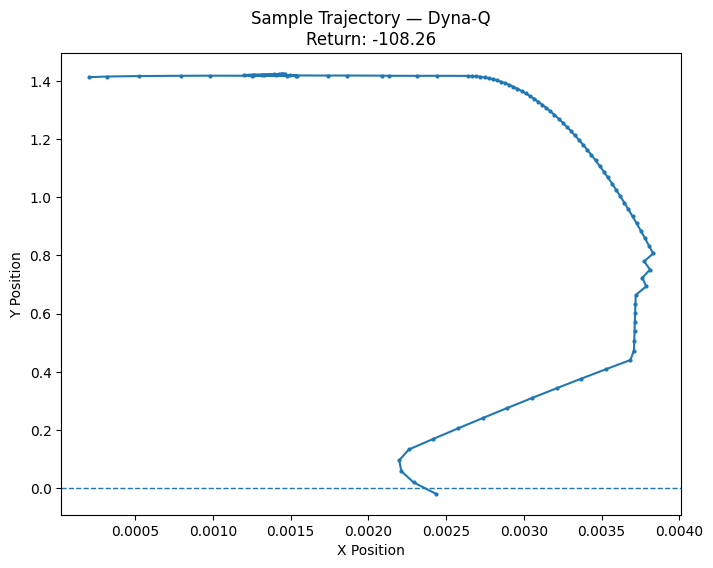

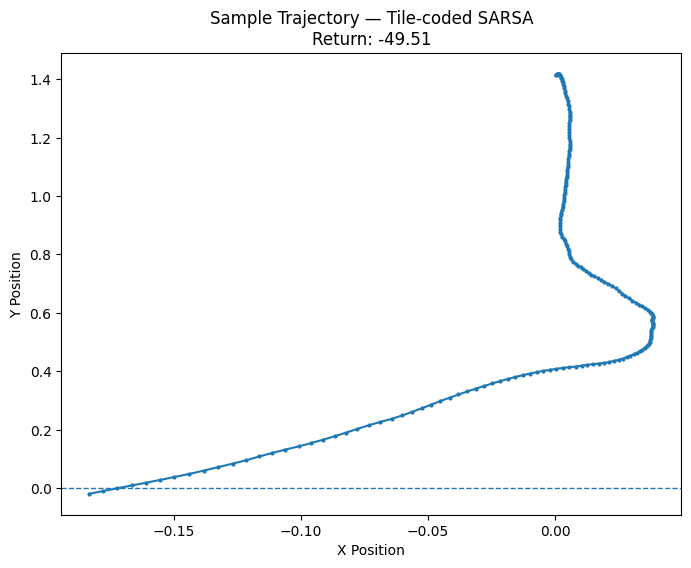

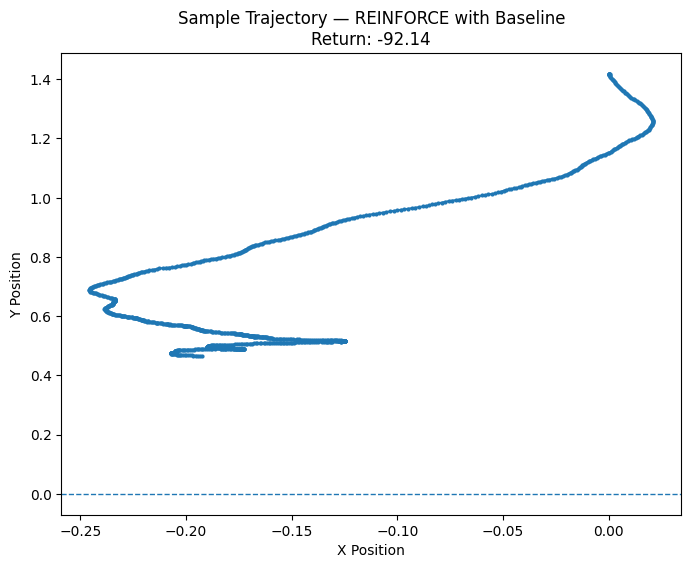

In [30]:
def plot_trajectory_xy(trajectory_dict, title):
    obs = trajectory_dict["observations"]

    x_pos = obs[:, 0]
    y_pos = obs[:, 1]

    plt.figure(figsize=(8, 6))

    plt.plot(x_pos, y_pos, marker="o", markersize=2)
    plt.axhline(0, linestyle="--", linewidth=1)

    plt.title(f"{title}\nReturn: {trajectory_dict['return']:.2f}")
    plt.xlabel("X Position")
    plt.ylabel("Y Position")
    plt.grid(False)
    plt.show()


dyna_traj = generate_dyna_trajectory(best_dyna_q, seed=999)
sarsa_traj = generate_sarsa_trajectory(best_tile_sarsa, seed=999)
reinforce_traj = generate_reinforce_trajectory(best_reinforce, seed=999)

plot_trajectory_xy(dyna_traj, "Sample Trajectory — Dyna-Q")
plot_trajectory_xy(sarsa_traj, "Sample Trajectory — Tile-coded SARSA")
plot_trajectory_xy(reinforce_traj, "Sample Trajectory — REINFORCE with Baseline")

### Saving Model Checkpoints

In [31]:
torch.save(
    best_reinforce["policy_net"].state_dict(),
    "checkpoints_week8/best_reinforce_baseline_policy_lunarlander.pt"
)

torch.save(
    best_reinforce["value_net"].state_dict(),
    "checkpoints_week8/best_reinforce_baseline_value_lunarlander.pt"
)

np.save(
    "checkpoints_week8/best_dyna_q_lunarlander_Q.npy",
    best_dyna_q["Q"]
)

np.save(
    "checkpoints_week8/best_tile_sarsa_lunarlander_weights.npy",
    best_tile_sarsa["weights"]
)

### Final Combined Tables

In [32]:
summary_df

,Algorithm,Final Mean Return,Final Std Return,Final Mean Length,Final Std Length,Best Seed Final Return,Worst Seed Final Return
0,Dyna-Q,-176.1,9.53,130.87,3.58,-169.84,-187.06
1,Tile-coded SARSA,-99.2,14.24,236.09,23.40,-83.55,-111.40
2,REINFORCE with Baseline,32.6,41.64,554.71,143.61,57.56,-15.47


In [33]:
eval_summary_df

,Algorithm,Eval Mean Return,Eval Std Return,Eval Mean Length,Best Training Seed Index
0,Dyna-Q,-250.23,103.89,188.75,1
1,Tile-coded SARSA,-98.80,187.22,282.20,1
2,REINFORCE with Baseline,-48.26,19.54,1000.00,2


In [34]:
if RUN_HYPERPARAMETER_TUNING:
    dyna_tuning_summary_df

In [35]:
if RUN_HYPERPARAMETER_TUNING:
    sarsa_tuning_summary_df

In [36]:
if RUN_HYPERPARAMETER_TUNING:
    reinforce_tuning_summary_df